# Sampling module

**What's in this notebook?** This notebook illustrates ... within JAXVacua.

(*Created:* Andreas Schachner, June 25, 2024)

## Imports

### General imports

In [1]:
import sys, os, warnings, time
import numpy as np
from tqdm.auto import tqdm
from functools import partial
from typing import Any, Callable, Sequence
from IPython.display import clear_output

import warnings
warnings.filterwarnings('ignore')

### JAX imports

In [2]:
from jax import jit, vmap
import jax 
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

# Set data type
DTYPE='float64'

# Set constants
pi = jnp.pi

from jax.typing import ArrayLike
from jax import Array
from jax.experimental import host_callback


### Plotting tools

In [3]:
import seaborn as sn
import matplotlib.pyplot as plt
import matplotlib as mpl
cmap=sn.color_palette("viridis", as_cmap=True)

### Custom library for EFT

In [4]:
sys.path.append("./../../../")

import jaxvacua
from jaxvacua.util import *

(CVXPY) Jun 18 03:39:07 PM: Encountered unexpected exception importing solver GLPK:
ImportError("cannot import name 'glpk' from 'cvxopt' (/home/cytools/cytools-venv/lib/python3.11/site-packages/cvxopt/__init__.py)")
(CVXPY) Jun 18 03:39:07 PM: Encountered unexpected exception importing solver GLPK_MI:
ImportError("cannot import name 'glpk' from 'cvxopt' (/home/cytools/cytools-venv/lib/python3.11/site-packages/cvxopt/__init__.py)")
(CVXPY) Jun 18 03:39:07 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Version of ortools (9.6.2534) is too old. Expected >= 9.7.0.')


TODO: Add function that converts M,K fluxes to full fluxes with and without coni-LCS?


## Sampling methods at $h^{1,2}=2$

Load model from files

In [5]:
#if False:
if True:
    h12=2
    model = jaxvacua.flux_sector_private(h12 = h12, Q=276, model_ID = 1, maximum_degree = 2,moduli_space_limit="LCS",model_type="KS")

Alternatively, use CYTools

In [6]:
from cytools import Polytope, Cone, fetch_polytopes, read_polytopes

if False:
    p = fetch_polytopes(h11=2,h12=272,limit=5,lattice="N",as_list=True)[0]
    cy = p.triangulate().get_cy()
    mcap = cy.mori_cone_cap(in_basis=True)
    Kcup = mcap.dual_cone()
    basis_trafo = Kcup.extremal_rays()

    model = jaxvacua.flux_sector(h12=cy.h11(), Q=cy.h11()+cy.h12()+2, model_type="KS", maximum_degree=2, 
                                      use_cytools=True, mirror_cy = cy, basis_transformation=basis_trafo)

As objective function, we take the $F$-terms for the moduli as computed in `model.DW`.
For later purposes, we vectorise this function by using `jax.vmap`:

In [7]:
DW_v = vmap(model.DW)

It is also convenient to introduce a data sampler that constrains our sampling procedure to specific regions in moduli and flux space:

In [8]:
sampler = jaxvacua.data_sampler(model,flux_bounds=[-5,5],moduli_bounds=[0,5],axion_bounds=[-0.5,0.5])

Restricted license - for non-production use only - expires 2025-11-24


For reproducability, we use a seed for random number generation

In [9]:
seed = 42
#rns_key = jaxvacua.PRNGSequence(seed)
np.random.rand(seed)

array([0.69932891, 0.41491626, 0.13587817, 0.50046593, 0.67715398,
       0.36696794, 0.04734452, 0.07118768, 0.49221283, 0.70320968,
       0.9436552 , 0.98157367, 0.88082157, 0.48223748, 0.11273102,
       0.45462791, 0.07180322, 0.31650794, 0.39433743, 0.7892905 ,
       0.3751978 , 0.15899257, 0.51862425, 0.60545688, 0.93401704,
       0.50861253, 0.23495275, 0.17920285, 0.24268425, 0.70017611,
       0.03523225, 0.96230939, 0.10092715, 0.03611019, 0.53132496,
       0.49347373, 0.55677874, 0.2235648 , 0.91533716, 0.6927226 ,
       0.28022978, 0.41422735])

Initial guesses can then be obtained as follows:

In [10]:
moduli,tau,fluxes = sampler.initial_guesses(5)
moduli,tau,fluxes

(Array([[ 0.47897799+1.08999368j,  0.14547923+4.75908216j],
        [-0.19152233+4.68828485j,  0.47552203+1.21229001j],
        [-0.32830304+1.46755699j,  0.28811039+3.84839905j],
        [ 0.18590741+3.44453782j, -0.30143036+3.82663048j],
        [-0.40317763+3.03108477j,  0.42314639+1.2372669j ]],      dtype=complex128),
 Array([ 0.0772819 +3.15855613j, -0.25522642+9.55767212j,
        -0.13319841+5.03330156j, -0.1067251 +7.8235328j ,
        -0.46071529+6.33416143j], dtype=complex128),
 Array([[ 1, -1, -1, -4, -3,  4, -4,  3, -5,  4, -3, -2],
        [-3, -4,  2,  3,  5,  3, -2,  0, -1,  3, -1,  5],
        [-4,  4, -2,  1,  0,  3, -3,  2,  4,  4,  0, -5],
        [ 0, -5,  4,  1,  5, -4, -5,  4, -2,  4,  0,  5],
        [-3,  1,  1, -5,  1, -3, -3, -3,  4,  4,  0,  5]], dtype=int64))

In [ ]:
sampler.update_interior_points(num_pts = 2000)

In [ ]:
len(sampler._cone_points),len(np.unique(sampler._cone_points,axis=0))

(2957, 2957)

Compute shortest distance to next point

In [56]:
pts = sampler._cone_points
norms = np.linalg.norm(pts,axis=1)

In [72]:
from scipy import spatial

eps = 0.1
dat = []
for i,pt in tqdm(enumerate(pts)):
    norm = norms[i]
    pts0 = np.delete(pts.copy(), i, 0)
    norms0 = np.delete(norms.copy(), i, 0)
    
    flag = ((norms0>norm-eps)&(norms0<norm+eps))
    pts0 = pts0[flag]
    
    if len(pts0)==0:
        
        pts0 = np.delete(pts.copy(), i, 0)
        norms0 = np.delete(norms.copy(), i, 0)
        
        flag = ((norms0>norm-10*eps)&(norms0<norm+10*eps))
        
        pts0 = pts0[flag]
        
    
    #sys.exit()
    
    distance,index = spatial.KDTree(pts0).query(pt)
    
    if np.isinf(distance):
        sys.exit()
    
    dat.append([distance,index])
    
dat = np.array(dat)

0it [00:00, ?it/s]

In [73]:
dis = dat[:,0]
np.mean(dis),np.min(dis),np.max(dis)

(0.021746755350031104, 8.177739965868706e-05, 9.899494936611665)

In [75]:
np.where(dis==np.max(dis))

(array([22705, 22733]),)

In [81]:
np.where(dis==np.min(dis))

(array([14805, 17603]),)

In [82]:
dat[:,1][14805]

657.0

In [85]:
pts[14805],pts[17603]

(array([0.47429216, 0.0652088 ]), array([0.47421068, 0.0652157 ]))

In [ ]:
dat

In [60]:
len(pts)

23825

### Sampling moduli values

As a quick illustration, we can compare the following ways of sampling moduli.
The default option for sampling modes `"cone"` and `"stretched_cone"` is using a linear solver from `gurobi` to solve the hyperplane constraints $H\cdot x\geq 0$.

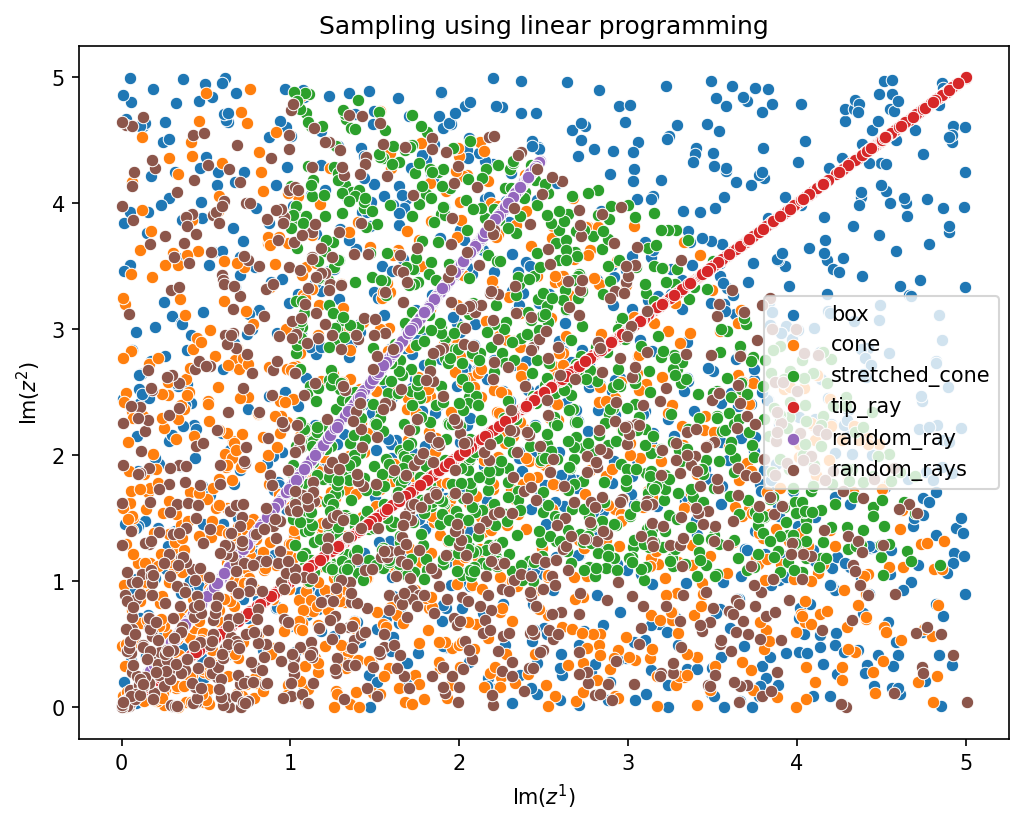

In [ ]:
sampling_modes = ["box","cone","stretched_cone","tip_ray","random_ray","random_rays"]
fig = plt.figure(dpi=150,figsize=(8,6))
for sampling_mode in sampling_modes:
    
    stretching = 0.
    if sampling_mode=="stretched_cone":
        stretching = 1.
        
    moduli = sampler.get_moduli(1000, 
                    sampling_mode = sampling_mode,
                    stretching  = stretching,
                    n_rays = 2,
                    perturbation = 1,
                    use_rays = False)
    
    sn.scatterplot(x=moduli[:,0],y=moduli[:,1],label=sampling_mode)
    
plt.xlabel(r"Im$(z^1)$")
plt.ylabel(r"Im$(z^2)$")
plt.title(r"Sampling using linear programming")
plt.show()

In [2]:
from cytools import Polytope
import numpy as np

p = Polytope(np.array([[ 0,  0, -1,  0,  0,  0,  1,  1, -1,  0],
       [ 0,  0,  0,  0,  1, -1, -1,  0,  0, -1],
       [ 1, -1,  0,  0,  0, -1,  0,  0,  0, -1],
       [ 0, -1,  1,  1,  0,  0,  0,  0,  0, -1]]).T)

p.chi("N")

-90

**different norms**

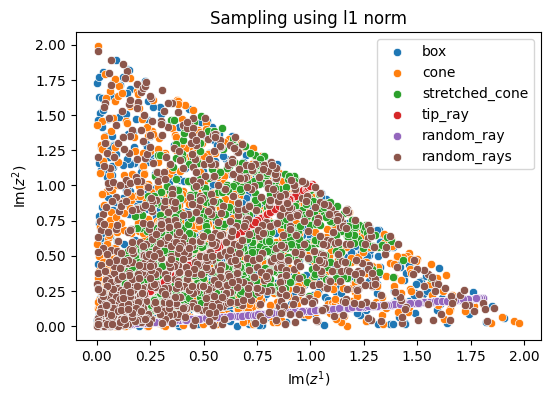

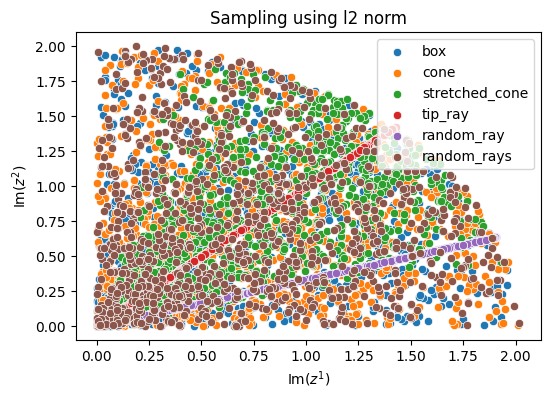

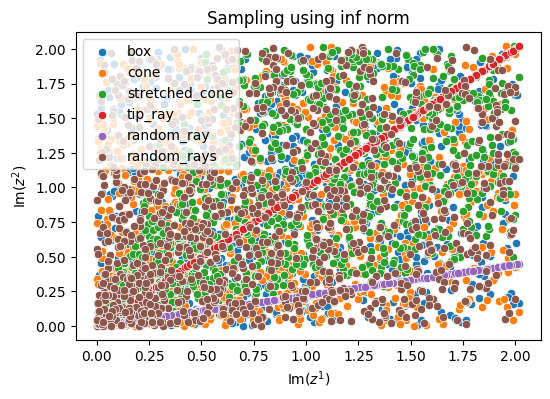

In [46]:
sampling_modes = ["box","cone","stretched_cone","tip_ray","random_ray","random_rays"]

for norm in ["l1","l2","inf"]:
    fig = plt.figure(dpi=100,figsize=(6,4))
    for sampling_mode in sampling_modes:

        stretching = 0.
        if sampling_mode=="stretched_cone":
            stretching = 1.

        moduli = sampler.get_moduli(1000, 
                        sampling_mode = sampling_mode,
                        stretching  = stretching,
                        n_rays = 2,
                        perturbation = 1,
                        use_rays = False)
        
        moduli = sampler.rescale_points(moduli,norm=norm,maxval=2)

        sn.scatterplot(x=moduli[:,0],y=moduli[:,1],label=sampling_mode)

    plt.xlabel(r"Im$(z^1)$")
    plt.ylabel(r"Im$(z^2)$")
    plt.title(r"Sampling using "+norm+" norm")
    plt.show()

We can also use rays for sampling modes `"cone"` and `"stretched_cone"`:

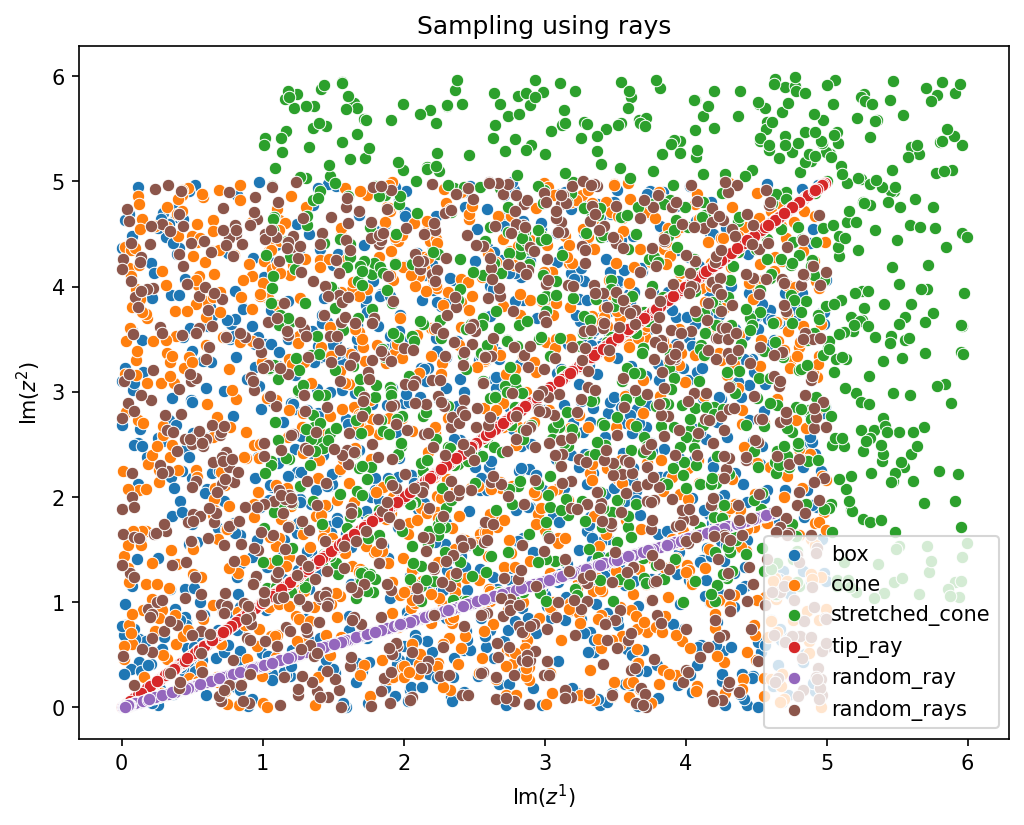

In [ ]:
sampling_modes = ["box","cone","stretched_cone","tip_ray","random_ray","random_rays"]
fig = plt.figure(dpi=150,figsize=(8,6))
for sampling_mode in sampling_modes:
    
    stretching = 0.
    if sampling_mode=="stretched_cone":
        stretching = 1.
        
    moduli = sampler.get_moduli(1000, 
                    sampling_mode = sampling_mode,
                    stretching  = stretching,
                    n_rays = 2,
                    perturbation = 1,
                    use_rays = True)
    
    sn.scatterplot(x=moduli[:,0],y=moduli[:,1],label=sampling_mode)
    
plt.xlabel(r"Im$(z^1)$")
plt.ylabel(r"Im$(z^2)$")
plt.title(r"Sampling using rays")
plt.show()

Here, we sample
* fluxes uniformly from a box set by the input parameter `flux_bounds` above,
* $\tau$ uniformly from its standard fundamental domain: $|\tau|\geq 1$, $|\text{Re}(\tau)|\leq 0.5$,
* $\text{Re}(z^i)$ uniformly from box as set by `axion_bounds` above,
* $\text{Im}(z^i)$ either uniformly from a box or the mirror Kähler cone (uniformly on the coefficients of the generators/rays)

**WARNING:** This is a really superficial sampling class that is not quite flexible enough for different

## ISD sampling

### General principle of ISD sampling

The general concept behind *ISD sampling* is that, instead of randomly choosing integer fluxes from some distribution, 
a subset of the fluxes can be replaced in favour of fixing values for the moduli, see in particular [2306.06160](https://arxiv.org/pdf/2306.06160).
In the process, the remaining fluxes can be fixed through the ISD condition $\star G_3 = \text{i}G_3$ where the Hodge-$\star$ depends explicitily on the moduli.
A clear advantage is that the ISD condition is **linear** in the fluxes and typically can be easily solved for given inputs.
(In contrast, when fixing all fluxes and solving the ISD condition for the moduli, one has to deal with highly non-trivial coupled equations in the moduli which can typically only be solved numerically.)
However, one immediate disadvantage is that the fluxes sampled through the ISD condition are typically not **quantised**.
But even after rounding the fluxes to integers, the chosen parameters approximately solve the ISD condition and hence serve as valuable starting guesses in a numerical search for flux vacua.

Below, we demonstrate the above idea in one single example before setting up a larger scan further below.
Let us choose initial guesses `z0` and `tau0` for the moduli $z^i_0$ and the axio-dilaton $\tau_0$
together with a choice `Hflux` of NSNS flux quanta $h$

In [15]:
# Moduli starting guesses
z0 = jnp.array([0.3+3j , 0.36+3.1j])

# Axio-dilaton starting guess
tau0 = -0.3+6.7j

# Choices of H-fluxes
Hflux = jnp.array([39., -13.,  -4.,   0.,  -0.,  0.])

Then, the RR-fluxes $f$ at the minimum are specified through the following version of the ISD condition

$$
    f=(s\,  M(z_0^i,\overline{z}_0^i)\Sigma + c_0)\, h\; ,\quad \tau_0=c_0 + \text{i} s \, .
$$

This particular version of ISD sampling was employed in [2501.03984](https://arxiv.org/abs/2501.03984).
Here, the ISD -matrix $M$ is computed from `model.ISD_matrix`:

In [16]:
s = tau0.imag
c0 = tau0.real
M = model.ISD_matrix(z0,jnp.conj(z0))

Fflux = jnp.matmul(M,jnp.matmul(model.periods.sigma(),Hflux))*s+c0*Hflux

Fflux.real

Array([ 3.67395227, -3.45606446, -2.3754192 , -2.33876273,  2.92189984,
        2.47605359], dtype=float64)

As expected, the fluxes obtained in this way are **not quantised**. 
For these values of the fluxes, the ISD condition or equivalently $D_IW=0$ is satisfied:

In [17]:
model.DW(z0,jnp.conj(z0),tau0,jnp.conj(tau0),jnp.append(Fflux.real,Hflux))

Array([ 8.52651283e-14-5.68434189e-14j,  2.13162821e-14-4.26325641e-14j,
       -1.42108547e-14+7.10542736e-15j], dtype=complex128)

To find an actual flux vacuum, we now round this choice to integers leading to

In [18]:
Fflux_rounded = jnp.around(Fflux.real,0)
fluxes0 = jnp.append(Fflux_rounded,Hflux)
fluxes0

Array([  4.,  -3.,  -2.,  -2.,   3.,   2.,  39., -13.,  -4.,   0.,  -0.,
         0.], dtype=float64)

The above steps have been collected in a single wrapper function `model.ISD_sampling` (see below for additional details)

In [19]:
fluxes0 = sampler.ISD_sampling(z0,jnp.conj(z0),tau0,jnp.conj(tau0),Hflux,mode="H",output="full",return_integer_flux=True).real
fluxes0

Array([  4,  -3,  -2,  -2,   3,   2,  39, -13,  -4,   0,   0,   0], dtype=int64)

However, since we changed the choices of RR-fluxes, the initial guesses `z0` and `tau0` do not correspond tothe acutal points
in moduli space at which the scalar potential is minimised as can be seen by computing $D_I W$:

In [20]:
model.DW(z0,jnp.conj(z0),tau0,jnp.conj(tau0),fluxes0)

Array([12.74030925-2.19173189j,  3.96347019-0.24168453j,
       -2.15788773+1.17152841j], dtype=complex128)

Nonetheless, the initial guesses `z0` and `tau0` are typically very close to an actual solution to $D_I W=0$
which we can e.g. find by employing Newton's method.

This is illustrated in the notebook [7_ISD_sampling_flux_vacua.ipynb](./7_ISD_sampling_flux_vacua.ipynb)

### Different versions of ISD sampling

Lastly, let describe the four modi to solve the ISD condition for a given choices of half of the fluxes.
Either we use the following form of the ISD condition

$$
    f_1-\tau h_1=\overline{\mathcal{N}}(z^i,\overline{z}^i)\, (f_2-\tau h_2)\, ,
$$

in terms of the gauge kinetic matrix $\mathcal{N}$ which can be computed using `model.gauge_kinetic_matrix`.
This expression can be solved for fluxes $(f_1,h_1)$ (corresponding to `mode="ISD+"`) 
or $(f_2,h_2)$ (associated to `mode="ISD-"`) corresponding to the components of the 
RR-flux vector $f=(f_1,f_2)$ and the NSNS-flux vector $h=(h_1,h_2)$
for given input values for the moduli $z^i$ and the axio-dilaton $\tau$.
The other two modi are obtained by rewriting the above expression in the following form

$$
    f=(s \, M(z^i,\overline{z}^i)\Sigma +  c_0)\, h\; ,\quad \tau=c_0 + \text{i} s \, .
$$

This can then be solved for RR-flux vector $f=(f_1,f_2)$ (`mode="F"`) 
or the NSNS-flux vector $h=(h_1,h_2)$ (`mode="H"`).

Using the same choice of fluxes and initial guesses as above, let us first collect

In [21]:
h1 = jnp.array([39., -13.,  -4.])
h2 = jnp.array([ 0.,  0.,  0.])
f1 = jnp.array([4.,  -3.,  -2.])
f2 = jnp.array([-2.,   3.,   2.])

# Choices of H-fluxes
Hflux = jnp.append(h1,h2)

# Choices of F-fluxes
Fflux = jnp.append(f1,f2)

# Choice for ISD+
ISDflux_plus = jnp.append(f2,h2)

# Choice for ISD-
ISDflux_minus = jnp.append(f1,h1)

Then the four different versions of ISD sampling can be used as follows

In [22]:
fluxes0 = sampler.ISD_sampling(z0,jnp.conj(z0),tau0,jnp.conj(tau0),Hflux,mode="H",output="full",return_integer_flux=True).real
fluxes0,np.sum(np.abs(model.DW(z0,jnp.conj(z0),tau0,jnp.conj(tau0),fluxes0)))

(Array([  4,  -3,  -2,  -2,   3,   2,  39, -13,  -4,   0,   0,   0], dtype=int64),
 19.353683708793397)

In [23]:
fluxes0 = sampler.ISD_sampling(z0,jnp.conj(z0),tau0,jnp.conj(tau0),Fflux,mode="F",output="full",return_integer_flux=True).real
fluxes0,np.sum(np.abs(model.DW(z0,jnp.conj(z0),tau0,jnp.conj(tau0),fluxes0)))

(Array([  4,  -3,  -2,  -2,   3,   2,  34, -12,  -4,   0,   0,   0], dtype=int64),
 4.466756522359235)

In [24]:
fluxes0 = sampler.ISD_sampling(z0,jnp.conj(z0),tau0,jnp.conj(tau0),ISDflux_plus,mode="ISD+",output="full",return_integer_flux=True).real
fluxes0,np.sum(np.abs(model.DW(z0,jnp.conj(z0),tau0,jnp.conj(tau0),fluxes0)))

(Array([  5,  -2,  -2,  -2,   3,   2,  34, -12,  -4,   0,   0,   0], dtype=int64),
 4.024474384034298)

In [25]:
fluxes0 = sampler.ISD_sampling(z0,jnp.conj(z0),tau0,jnp.conj(tau0),ISDflux_minus,mode="ISD-",output="full",return_integer_flux=True).real
fluxes0,np.sum(np.abs(model.DW(z0,jnp.conj(z0),tau0,jnp.conj(tau0),fluxes0)))

(Array([  4,  -3,  -2,  -2,   3,   2,  39, -13,  -4,   0,   0,   0], dtype=int64),
 19.353683708793397)

We notice that we do not always obtain the same choice of `fluxes0` for each version.
This is because the different versions ISD sampling find only the **closest integer flux vector** satisfying the ISD condition
for the given input of moduli values.

### Vectorising ISD sampling

We also provide the optional argument to vectorise ISD sampling accross many input points.
To do so, we set `vmap=True` and `in_axes=(0,0,None)` where the latter implies that we are vectorising over moduli and the axio-dilaton, but not over fluxes.
This gives use

In [29]:
np.random.seed(1)
moduli,tau = sampler.initial_guesses(100,include_fluxes=False)
fluxes0 = sampler.ISD_sampling(moduli,jnp.conj(moduli),tau,jnp.conj(tau),ISDflux_plus,mode="ISD+",output="full",return_integer_flux=True,
                     in_axes=(0,0,None),vmap=True)

fluxes0[:5]

Array([[  4,  -6,  -3,  -2,   3,   2, 162, -28,  -9,   0,   0,   0],
       [  3, -13,  -6,  -2,   3,   2,  14, -31,  -1,   0,   0,   0],
       [  5,  17,   4,  -2,   3,   2,  17,  -7,  -2,   0,   0,   0],
       [  7,   9,   2,  -2,   3,   2,   3,  -7,  -2,   0,   0,   0],
       [  1,  -1,  -4,  -2,   3,   2,   3,  -6,  -1,   0,   0,   0]],      dtype=int64)

Expected, certain components of the flux vector are always constant because they are specified by `ISDflux_plus=(-2.,  3.,  2.,  0.,  0.,  0.)`.

Alternatively, we can also evaluate the same function accross many different input fluxes as follows:

In [32]:
np.random.seed(1)
moduli,tau,ISDfluxes = sampler.initial_guesses(100,include_fluxes=True)
fluxes0 = sampler.ISD_sampling(moduli,jnp.conj(moduli),tau,jnp.conj(tau),ISDfluxes[:,:model.n_fluxes],mode="ISD+",output="full",return_integer_flux=True,
                     in_axes=(0,0,0),vmap=True)

fluxes0[:5]

Array([[4510,  564,  176,    3,    2,   -4, -214,   17,    6,    3,    5,
           2],
       [-412,  974,   18,    0,   -2,    0,    3,   20,    7,    4,    5,
          -3],
       [ 685, -532,  -88,   -4,    3,   -4,   22,  -12,   -4,    1,   -3,
           1],
       [  43,  -75,  -16,   -5,   -5,    5,    4,    8,    0,    2,   -2,
           4],
       [  50, -112,   -1,    5,    0,    5,  -11,   -1,   -3,   -2,   -2,
           1]], dtype=int64)